# BEE2041 Empirical Project: What property and location factors determine Airbnb listing prices in London?
## 03_data_analysis

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load cleaned data
df = pd.read_csv("../data/cleaned/london_clean.csv")

df.head()
df.shape

(46390, 21)

In [5]:
# Check data
print(df.describe())
print(df.info())

              price  accommodates      bedrooms          beds     bathrooms  \
count  46390.000000  46390.000000  46390.000000  46390.000000  46390.000000   
mean     165.860293      3.505691      1.522979      1.946626      1.333854   
std      134.780096      2.132426      0.944321      1.366142      0.635381   
min       10.000000      1.000000      0.000000      0.000000      0.000000   
25%       75.000000      2.000000      1.000000      1.000000      1.000000   
50%      130.000000      3.000000      1.000000      2.000000      1.000000   
75%      207.000000      4.000000      2.000000      2.000000      1.500000   
max     1000.000000     16.000000     12.000000     24.000000     12.500000   

           latitude     longitude  review_scores_rating  number_of_reviews  \
count  46390.000000  46390.000000          46390.000000       46390.000000   
mean      51.509342     -0.131692              4.671137          34.786333   
std        0.049056      0.102481              0.51355

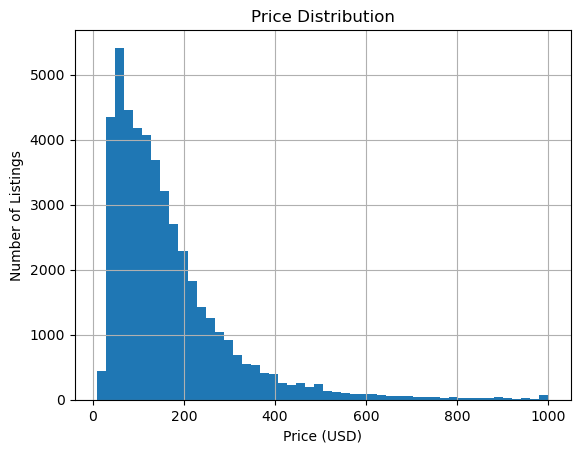

In [6]:
# Plot price distribution
df["price"].hist(bins=50)

# Label axes
plt.title("Price Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Listings")

# Save figure locally
plt.savefig("../figures/03_price_dist.png")

# Show figure
plt.show()

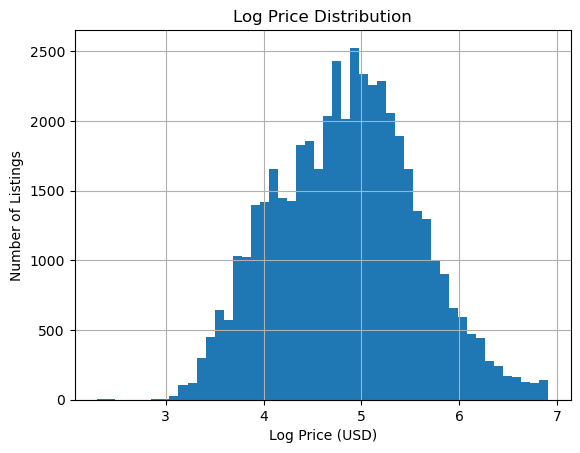

In [7]:
# Plot log_price distribution
df["log_price"].hist(bins=50)

# Label axes
plt.title("Log Price Distribution")
plt.xlabel("Log Price (USD)")
plt.ylabel("Number of Listings")

# Save figure locally
plt.savefig("../figures/03_log_price_dist.png")

# Show figure
plt.show()

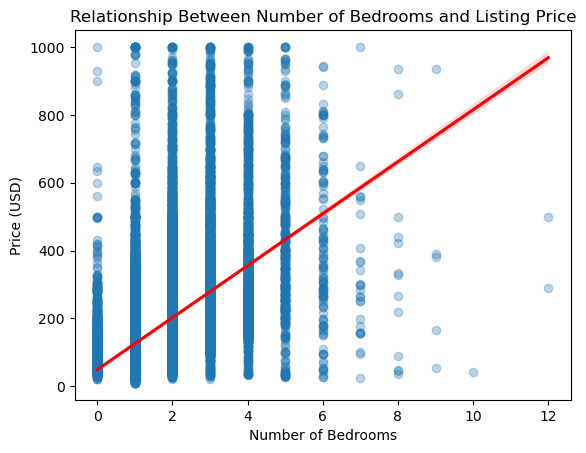

In [8]:
# Plotting number of bedrooms against price
sns.regplot(data=df, x="bedrooms", y="price", scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

# Label axes
plt.title("Relationship Between Number of Bedrooms and Listing Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price (USD)")

# Save figure
plt.savefig("../figures/03_bedrooms_price.png")

# Show figure
plt.show()

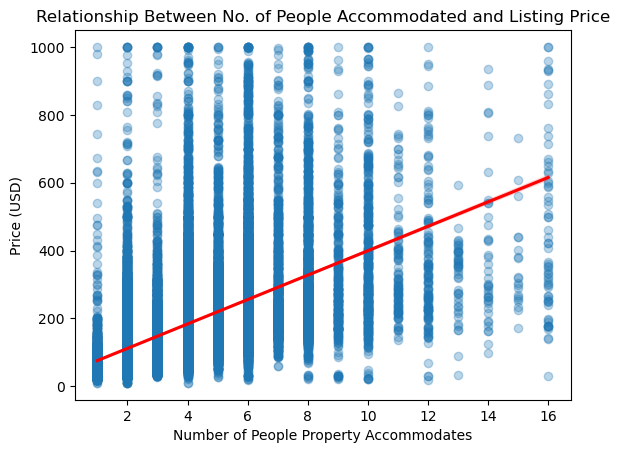

In [18]:
# Plotting number of bedrooms against price
sns.regplot(data=df, x="accommodates", y="price", scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

# Label axes
plt.title("Relationship Between No. of People Accommodated and Listing Price")
plt.xlabel("Number of People Property Accommodates")
plt.ylabel("Price (USD)")

# Save figure
plt.savefig("../figures/03_accommodates_price.png")

# Show figure
plt.show()

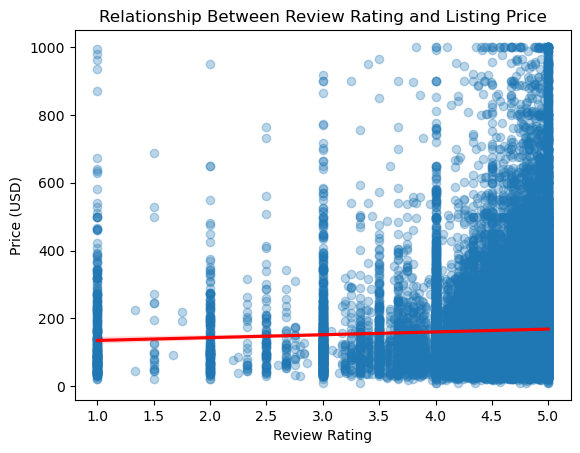

In [22]:
# Plotting review rating against price
sns.regplot(data=df, x="review_scores_rating", y="price", scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

# Label axes
plt.title("Relationship Between Review Rating and Listing Price")
plt.xlabel("Review Rating")
plt.ylabel("Price (USD)")

# Save figure
plt.savefig("../figures/03_review_rating_price.png")

# Show figure
plt.show()

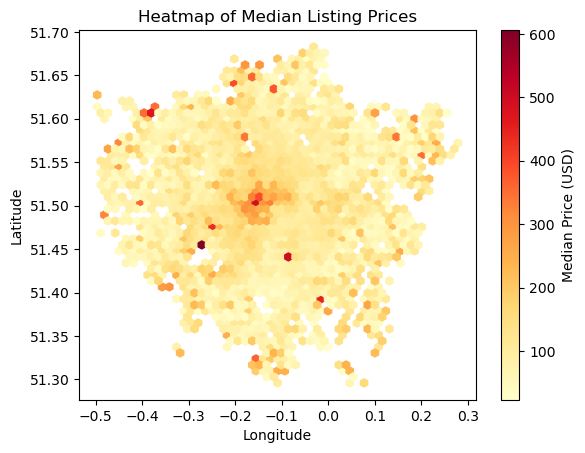

In [38]:
# Create heatmap
plt.hexbin(df['longitude'], df['latitude'], C=df['price'], gridsize=50, cmap='YlOrRd', reduce_C_function=np.median)

# Add legend
plt.colorbar(label='Median Price (USD)')

# Add labels
plt.title("Heatmap of Median Listing Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Save figure
plt.savefig("../figures/03_longitude_latitude.png")

# Show figure
plt.show()

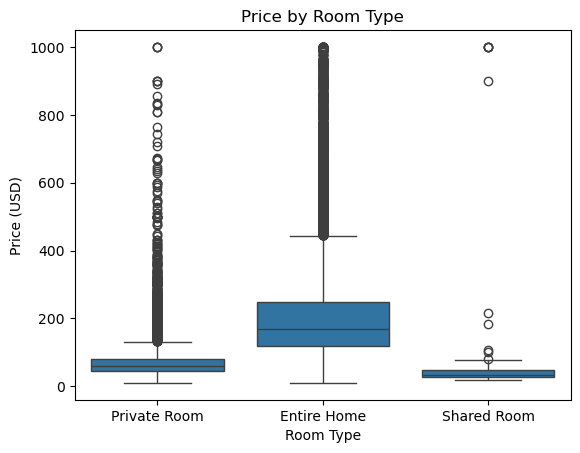

In [57]:
# Label type of room
df["room_type_clean"] = df.apply(
    lambda row: "Entire Home"
    if row.get("room_type_Private room", 0) == 0 and row.get("room_type_Shared room", 0) == 0
    else "Private Room"
    if row.get("room_type_Private room", 0) == 1
    else "Shared Room",
    axis=1
)

# Plot room type and price on a boxplot
sns.boxplot(x="room_type_clean", y="price", data=df)

# Add labels
plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price (USD)")

# Save figure
plt.savefig("../figures/03_price_room_type.png")

# Show figure
plt.show()

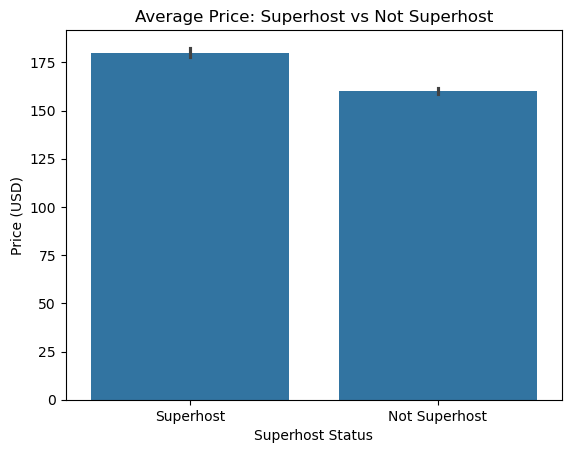

In [69]:
# Add superhost clean labels
df["superhost_clean"] = df["host_is_superhost"].map({
    1: "Superhost",
    0: "Not Superhost"
})

# Plot superhost and price
sns.barplot(x="superhost_clean", y="price", data=df)

# Add labels
plt.title("Average Price: Superhost vs Not Superhost")
plt.xlabel("Superhost Status")
plt.ylabel("Price (USD)")

# Save figure
plt.savefig("../figures/03_superhost_price.png")

# Show figure
plt.show()